In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PATH1_raw = '/glade/derecho/scratch/mmarkina/archive/a.e30.A_JRA55raw.TL319_t232.time_varying_HadOIBl/cpl/hist/'
PATH2_raw = '/glade/derecho/scratch/mmarkina/archive/a.e30.A_JRA.TL319_t232.time_varying_HadOIBl/cpl/hist/'

filename1_raw = 'a.e30.A_JRA55raw.TL319_t232.time_varying_HadOIBl.cpl.hi.1959-12-31-64800.nc'
filename2_raw = 'a.e30.A_JRA.TL319_t232.time_varying_HadOIBl.cpl.hi.1959-12-31-64800.nc'

lat1_raw = xr.open_dataset(PATH1_raw + filename1_raw, engine="netcdf4")['ocnExp_lat'].isel(time=0, drop = True).rename({"ocnExp_ny": "y", "ocnExp_nx": "x"})
lat2_raw = xr.open_dataset(PATH2_raw + filename2_raw, engine="netcdf4")['ocnExp_lat'].isel(time=0, drop = True).rename({"ocnExp_ny": "y", "ocnExp_nx": "x"})

mask1 = xr.open_dataset(PATH1_raw + filename1_raw, engine="netcdf4")['ocnImp_So_omask'].isel(time=0, drop = True).rename({"ocnImp_ny": "y", "ocnImp_nx": "x"})
mask2 = xr.open_dataset(PATH2_raw + filename2_raw, engine="netcdf4")['ocnImp_So_omask'].isel(time=0, drop = True).rename({"ocnImp_ny": "y", "ocnImp_nx": "x"})

# mask1 = mask1.where(mask1 != 0, np.nan)
# mask2 = mask2.where(mask2 != 0, np.nan)


In [3]:
##  Bits of all code showing the area from model output I've been using
# area1_raw = xr.open_dataset(PATH1_raw + filename1_raw, engine="netcdf4")['MED_ocn_area'].isel(time=0)
# area2_raw = xr.open_dataset(PATH2_raw + filename2_raw, engine="netcdf4")['MED_ocn_area'].isel(time=0)

# R2 = 6371e3**2
# area1 = (area1_raw*R2).rename({"MED_ocn_ny": "y", "MED_ocn_nx": "x"})
# area2 = (area2_raw*R2).rename({"MED_ocn_ny": "y", "MED_ocn_nx": "x"})

# weights1 = ((mask1 * area1)/np.sum(area1*mask1))
# weights1 = weights1.fillna(0)

# weights2 = ((mask2 * area2)/np.sum(area2*mask2))
# weights2 = weights2.fillna(0)

<xarray.DataArray ()> Size: 8B
array(1.)

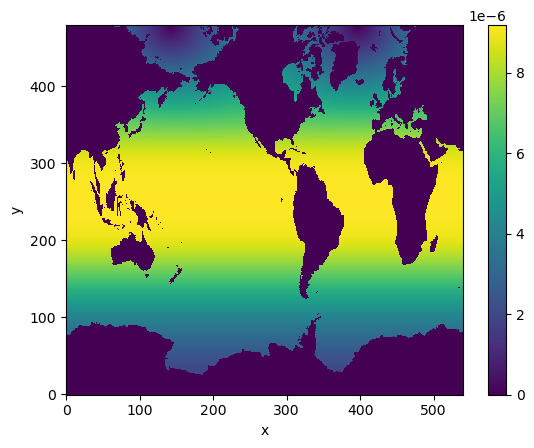

In [4]:
weights_1 = np.cos(np.deg2rad(lat1_raw))*mask1
weights_1 = weights_1 / weights_1.sum()  # Normalize so they sum to 1
# weights_1 = weights_1.broadcast_like(swdn125['swdn'])  # Ensure shape matches the data variable
weights_1.plot()
weights_1.sum()

<xarray.DataArray ()> Size: 8B
array(1.)

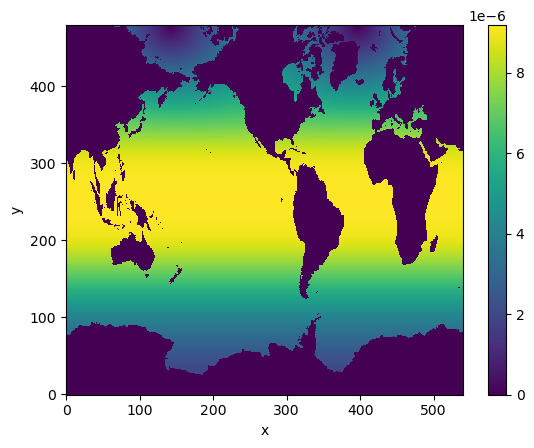

In [5]:
weights_2 = np.cos(np.deg2rad(lat2_raw)) *mask2
weights_2 = weights_2 / weights_2.sum()  # Normalize so they sum to 1
weights_2.plot()
weights_2.sum()

In [6]:
PATH1 = "/glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_JRA55raw.TL319_t232.time_varying_HadOIBl/MONTHLY/" 
PATH2 = "/glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_JRA.TL319_t232.time_varying_HadOIBl/MONTHLY/"  


file_names1 = {
    "swnet": "swnet_1958_1959.nc.1",
    "lwnet": "lwnet_1958_1959.nc.1",
    "latent": "latent_1958_1959.nc.1",
    "sensible": "sensible_1958_1959.nc.1",
}

file_names2 = {
    "swnet": "swnet_1958_1995.nc",
    "lwnet": "lwnet_1958_1995.nc",
    "latent": "latent_1958_1995.nc",
    "sensible": "sensible_1958_1995.nc",
}

In [7]:
# Ranaming dims in raw 

for var in ["swnet", "lwnet", "latent", "sensible"]:
    
    ds = xr.open_dataset(PATH1 + var + "_1958_1959.nc")
    ds = ds.rename({"ocnExp_nx": "x", "ocnExp_ny": "y"})
    ds.to_netcdf(PATH1 + var + "_1958_1959.nc.1")

/glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_JRA55raw.TL319_t232.time_varying_HadOIBl/MONTHLY/
<xarray.DataArray ()> Size: 8B
array(0)
<xarray.DataArray ()> Size: 8B
array(0)
<xarray.DataArray ()> Size: 8B
array(0)
<xarray.DataArray ()> Size: 8B
array(0)
/glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_JRA.TL319_t232.time_varying_HadOIBl/MONTHLY/
<xarray.DataArray ()> Size: 8B
array(0)
<xarray.DataArray ()> Size: 8B
array(0)
<xarray.DataArray ()> Size: 8B
array(0)
<xarray.DataArray ()> Size: 8B
array(0)


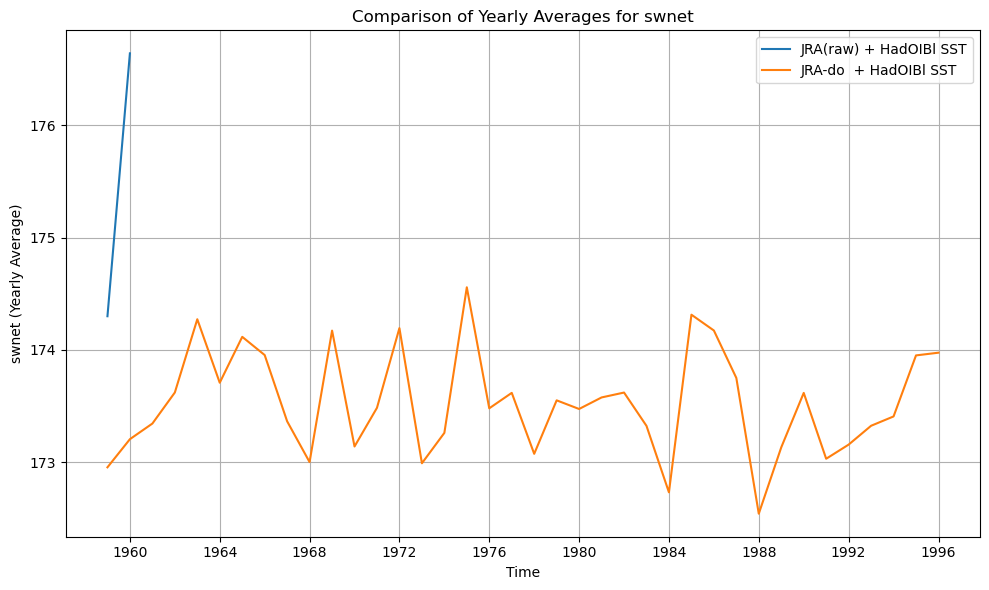

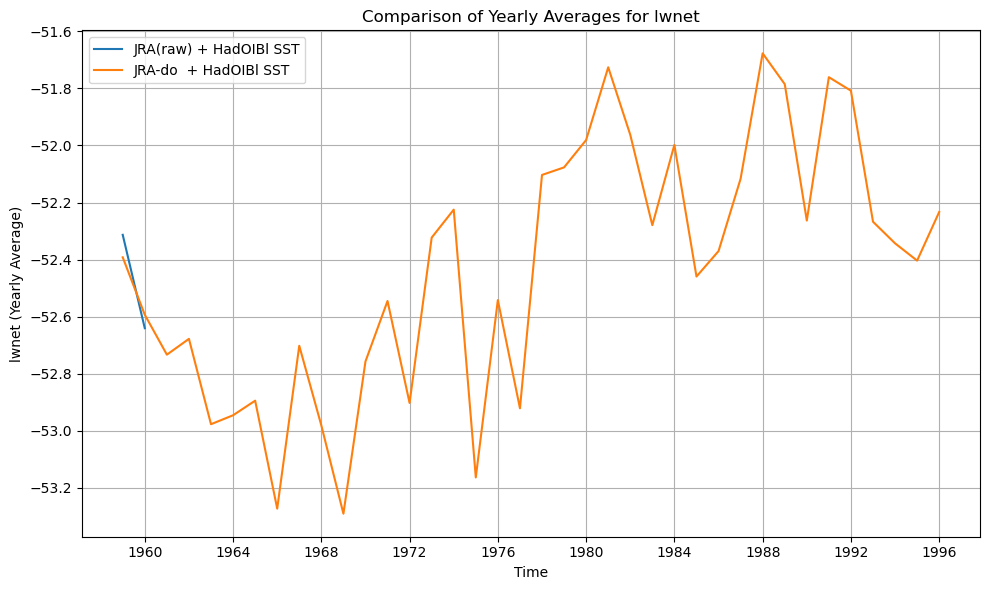

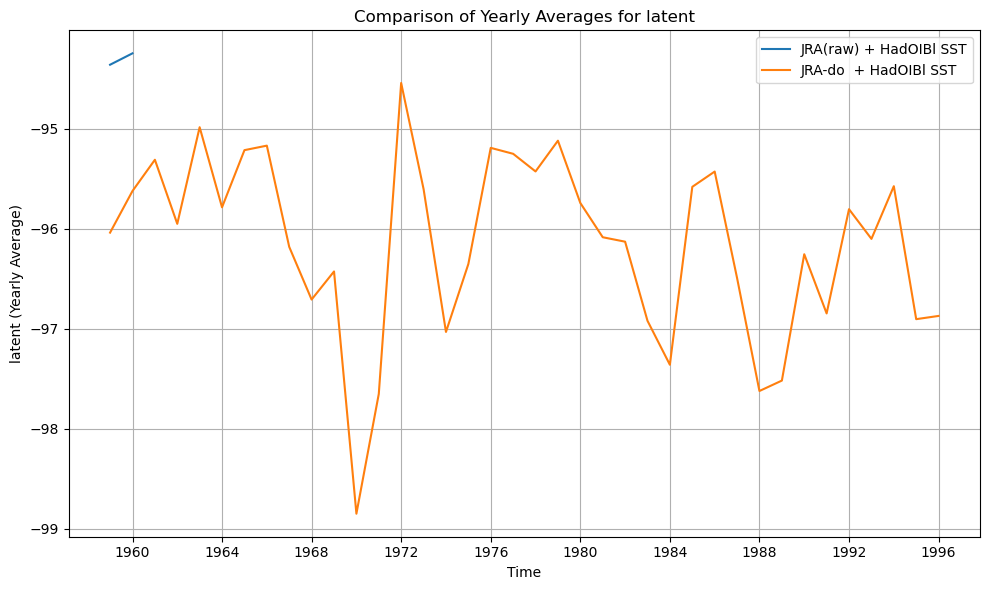

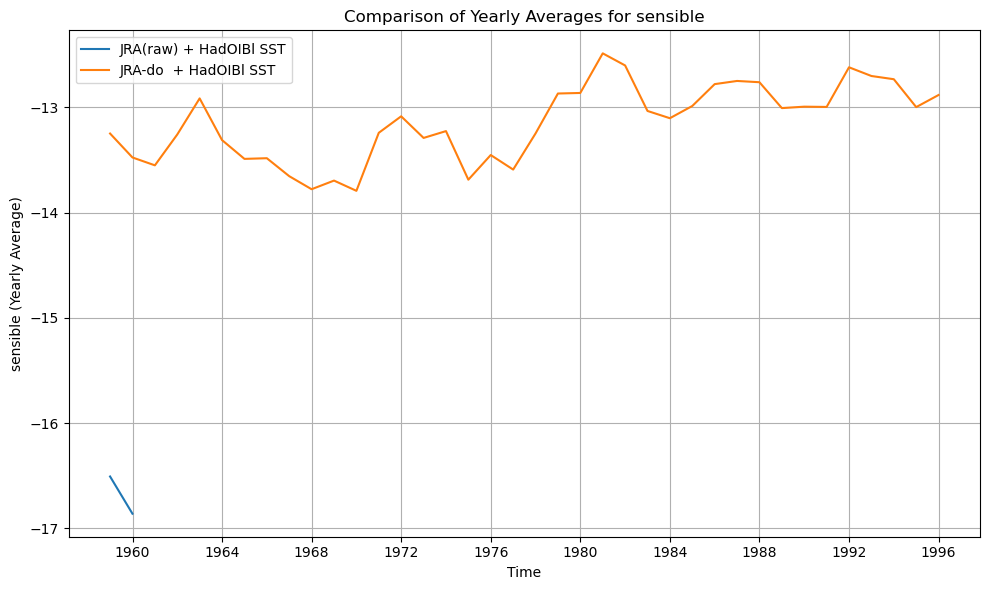

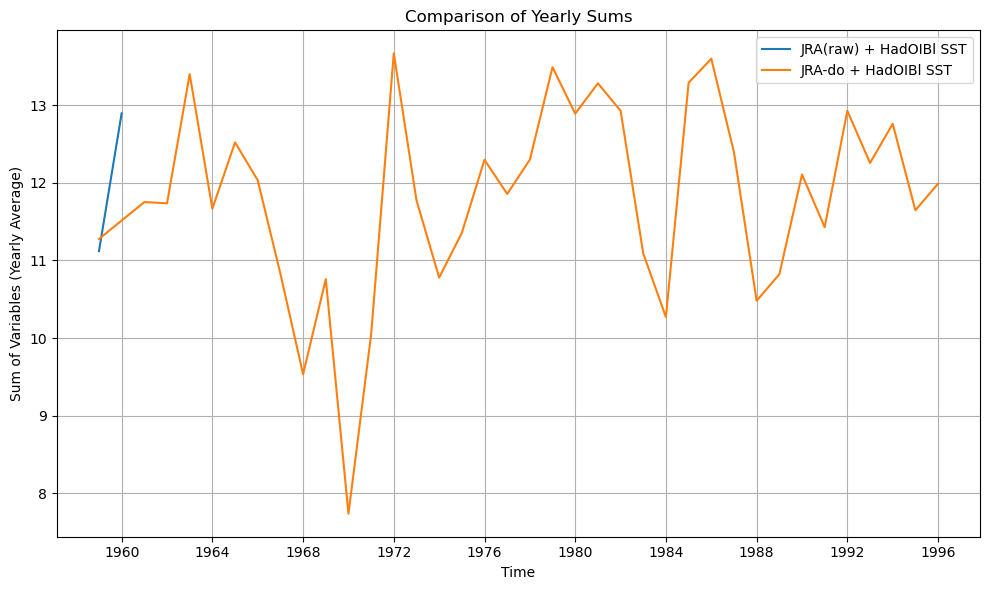

CPU times: user 7.53 s, sys: 6.41 s, total: 13.9 s
Wall time: 21.3 s


In [8]:
%%time


def process_dataset(path, file_names, weights, variable_names):
    print(path)
    yearly_means = {}
    for key, file_name in file_names.items():
        ds = xr.open_dataset(path + file_name, engine="netcdf4")
        var_name = variable_names[key]

        weights_br = weights.broadcast_like(ds[var_name])  # Ensure shape matches the data variable
        nan_counts = weights_br.isnull().sum()
        print(nan_counts)

        var_time_series = ds[var_name].weighted(weights_br).mean(dim=["x", "y"])
        var_time_series["time"] = pd.to_datetime([t.strftime('%Y-%m-%d') for t in var_time_series["time"].values])
        yearly_mean = var_time_series.resample(time="1YE").mean()
        yearly_means[key] = yearly_mean

        del weights_br
        
    yearly_means["sum"] = sum(yearly_means.values())
    return yearly_means



variable_names = {
    "swnet": "ocnExp_Foxx_swnet",
    "lwnet": "ocnExp_Foxx_lwnet",
    "latent": "ocnExp_Foxx_lat",
    "sensible": "ocnExp_Foxx_sen",
}

# Process all datasets
yearly_means1 = process_dataset(PATH1, file_names1, weights_1, variable_names)
yearly_means2 = process_dataset(PATH2, file_names2, weights_2, variable_names)

# Plot comparison for each variable
for key in file_names2.keys():
    plt.figure(figsize=(10, 6))
    plt.plot(yearly_means1[key]["time"], yearly_means1[key], label=f"JRA(raw) + HadOIBl SST")
    plt.plot(yearly_means2[key]["time"], yearly_means2[key], label=f"JRA-do  + HadOIBl SST")
    plt.xlabel("Time")
    plt.ylabel(f"{key} (Yearly Average)")
    plt.title(f"Comparison of Yearly Averages for {key}")
    # plt.xlim(1940,2020) 
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

# Plot comparison for the sum of variables
plt.figure(figsize=(10, 6))
plt.plot(yearly_means1["sum"]["time"], yearly_means1["sum"], label="JRA(raw) + HadOIBl SST")
plt.plot(yearly_means2["sum"]["time"], yearly_means2["sum"], label="JRA-do + HadOIBl SST")
# plt.plot(yearly_means3["sum"]["time"], yearly_means3["sum"], label="ERA5 Sum")
plt.xlabel("Time")
# plt.xlim(1940, 2020) 
plt.ylabel("Sum of Variables (Yearly Average)")
plt.title("Comparison of Yearly Sums")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [16]:
ds = xr.open_dataset(PATH2 + "swnet_1958_1995.nc", engine="netcdf4")


nan_counts = ds["ocnExp_Foxx_swnet"].isnull().sum()
print(nan_counts)

<xarray.DataArray 'ocnExp_Foxx_swnet' ()> Size: 8B
array(0)


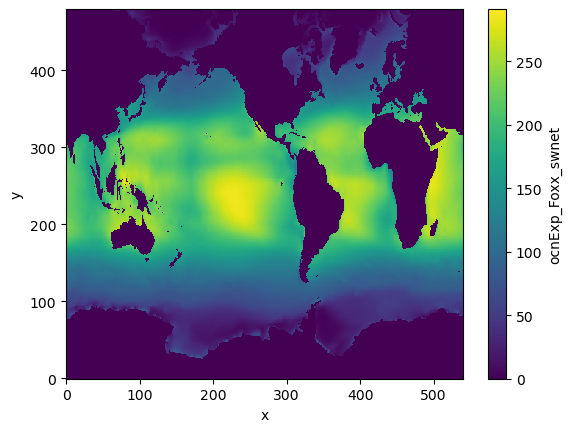

In [17]:
ds["ocnExp_Foxx_swnet"].mean('time').plot()

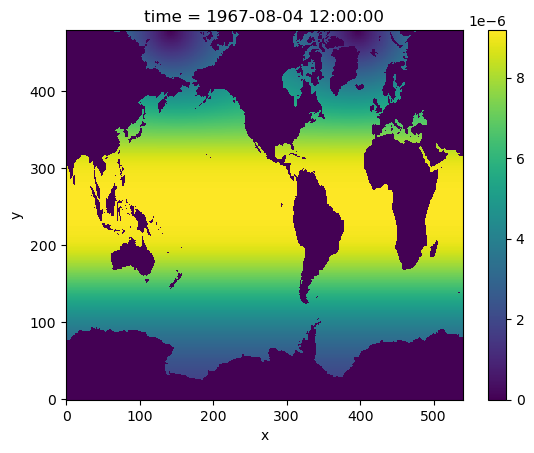

In [59]:
weights_1.broadcast_like(ds["ocnExp_Foxx_lwnet"]).isel(time=-1).plot()

In [60]:
nan_counts = weights_1.broadcast_like(ds["ocnExp_Foxx_lwnet"]).isnull().sum()
print(nan_counts)

<xarray.DataArray ()> Size: 8B
array(0)
